In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('data/athlete_events.csv')
noc = pd.read_csv('data/noc_regions.csv')
df = df.merge(noc[['NOC', 'region']], on='NOC', how='left')
print(f'Loaded {len(df)} rows, {df.shape[1]} columns')

Loaded 271116 rows, 16 columns


# Viz 1: Women's share of Olympic competitors over time

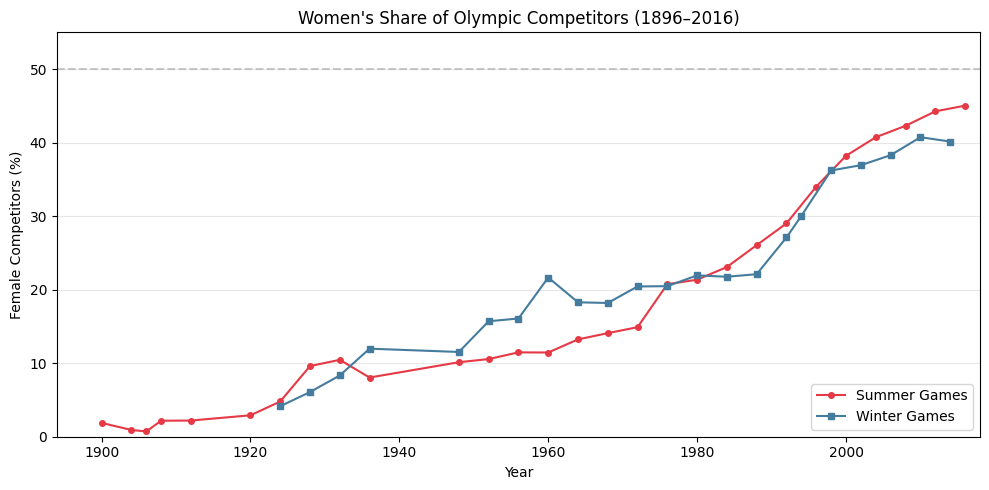

In [2]:

gender = df.groupby(['Year', 'Season', 'Sex'])['ID'].nunique().reset_index(name='count')
total = gender.groupby(['Year', 'Season'])['count'].transform('sum')
gender['pct'] = gender['count'] / total * 100
female = gender[gender['Sex'] == 'F']

summer_f = female[female['Season'] == 'Summer'].sort_values('Year')
winter_f = female[female['Season'] == 'Winter'].sort_values('Year')

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(summer_f['Year'], summer_f['pct'], 'o-', color='#E63946', label='Summer Games', markersize=4)
ax.plot(winter_f['Year'], winter_f['pct'], 's-', color='#457B9D', label='Winter Games', markersize=4)
ax.axhline(y=50, color='gray', linestyle='--', alpha=0.4)
ax.set_xlabel('Year')
ax.set_ylabel('Female Competitors (%)')
ax.set_title("Women's Share of Olympic Competitors (1896\u20132016)")
ax.legend()
ax.set_xlim(1894, 2018)
ax.set_ylim(0, 55)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('viz1_gender_participation.png', dpi=150)
plt.show()